# 3Y0K Bouvet Island — DXpedition Propagation Analysis

**Callsign**: 3Y0K | **Entity**: Bouvet Island | **Grid**: JD04 (54.4°S, 3.4°E)  
**Operation**: 2026-03-01 to 2026-03-14 (14 days)  
**Modes**: CW, FT8, FT4, RTTY, FM | **Bands**: All 10 HF (160m–10m)  

#2 most wanted DXCC entity per Club Log. First major activation since 3Y0J in 2023 from one of
the most remote islands on Earth. A geomagnetic storm (Kp 6.0) struck during
the final days of operation.

**Data**: 3,209 RBN spots + 6,416 PSKR signatures | **SFI**: 111.6–147.6 | **Kp**: 0.0–6.0  
**Dataset**: [SourceForge](https://sourceforge.net/projects/ionis-ai/files/dxpeditions/)  

Analysis by [IONIS-AI](https://github.com/IONIS-AI) and [QSO-Graph](https://github.com/qso-graph).

## Setup — DXpedition Parameters

In [1]:
import sqlite3
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("cartopy not installed — map plots will be skipped")

from ionis_jupyter.grids import grid_to_latlon, grid_distance, grid_bearing
from ionis_jupyter.solar import (
    solar_elevation_grid, is_dark_grid, classify_path
)
from ionis_jupyter.loader import band_name

# Plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.3,
})

cartopy not installed — map plots will be skipped


In [2]:

CALLSIGN       = "3Y0K"
ENTITY         = "Bouvet Island"
GRID           = "JD04"
START_UTC      = "2026-03-01"
END_UTC        = "2026-03-14"
MODES          = ["CW", "FT8", "FT4", "RTTY", "FM"]
BANDS_ALL      = True  # All 10 HF bands including WARC

# Dataset filename (must be in same directory or data/ subdirectory)
DB_FILENAME    = "3y0k-bouvet-island-2026.sqlite"

## Load DXpedition Dataset

In [3]:
# Find the dataset
# Priority: local data/ directory, then same directory, then IONIS_DATA_DIR
import os

_search_paths = [
    Path("data") / DB_FILENAME,
    Path(DB_FILENAME),
    Path(os.environ.get("IONIS_DATA_DIR", "")) / DB_FILENAME,
]

db_path = None
for p in _search_paths:
    if p.exists():
        db_path = p
        break

if db_path is None:
    raise FileNotFoundError(
        f"Dataset {DB_FILENAME} not found. "
        f"Download from SourceForge: ionis-ai/files/dxpeditions/"
    )

print(f"Using dataset: {db_path}")

Using dataset: 3y0k-bouvet-island-2026.sqlite


In [4]:
# Load all tables
conn = sqlite3.connect(str(db_path))

# DXpedition metadata
dxpe_info = pd.read_sql("SELECT * FROM dxpedition_info", conn).iloc[0]

# Raw RBN spots
rbn_spots = pd.read_sql("SELECT * FROM rbn_spots", conn)
rbn_spots["timestamp"] = pd.to_datetime(rbn_spots["timestamp"])

# RBN signatures (13-column standard)
rbn_sigs = pd.read_sql("SELECT * FROM rbn_signatures", conn)

# PSKR signatures (13-column standard)
pskr_sigs = pd.read_sql("SELECT * FROM pskr_signatures", conn)

# Solar timeline
solar = pd.read_sql("SELECT * FROM solar_timeline", conn)
solar["datetime"] = pd.to_datetime(solar["date"]) + pd.to_timedelta(solar["hour"], unit="h")

conn.close()

# Band ID to name mapping
BAND_ORDER = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111]
BAND_NAMES = {b: band_name(b) for b in BAND_ORDER}

# DXpedition grid coordinates
DX_LAT, DX_LON = grid_to_latlon(GRID)

print(f"Loaded: {CALLSIGN} — {ENTITY} ({GRID})")
print(f"  RBN spots:      {len(rbn_spots):,}")
print(f"  RBN signatures: {len(rbn_sigs):,}")
print(f"  PSKR signatures:{len(pskr_sigs):,}")
print(f"  Solar timeline: {len(solar):,} rows")
print(f"  Operation:      {START_UTC} to {END_UTC}")
print(f"  SFI range:      {dxpe_info['sfi_min']:.1f} – {dxpe_info['sfi_max']:.1f}")
print(f"  Kp range:       {dxpe_info['kp_min']:.1f} – {dxpe_info['kp_max']:.1f}")

Loaded: 3Y0K — Bouvet Island (JD04)
  RBN spots:      3,209
  RBN signatures: 548
  PSKR signatures:6,416
  Solar timeline: 144 rows
  Operation:      2026-03-01 to 2026-03-14
  SFI range:      111.6 – 147.6
  Kp range:       0.0 – 6.0


---

## Section 1 — DXpedition Overview

In [5]:
# DXpedition summary card
print("=" * 60)
print(f"{CALLSIGN} — {ENTITY}")
print("=" * 60)
print(f"Grid:           {GRID} ({DX_LAT:.1f}°N, {DX_LON:.1f}°E)")
print(f"Operation:      {START_UTC} to {END_UTC}")
print(f"Modes:          {dxpe_info['modes']}")
print(f"Bands:          {dxpe_info['bands']}")
print(f"RBN spots:      {dxpe_info['rbn_spot_count']:,.0f}")
print(f"PSKR spots:     {dxpe_info['pskr_spot_count']:,.0f}")
print(f"RBN signatures: {dxpe_info['rbn_sig_count']:,.0f}")
print(f"PSKR signatures:{dxpe_info['pskr_sig_count']:,.0f}")
print(f"SFI:            {dxpe_info['sfi_min']:.1f} – {dxpe_info['sfi_max']:.1f} (avg {dxpe_info['sfi_avg']:.1f})")
print(f"Kp:             {dxpe_info['kp_min']:.1f} – {dxpe_info['kp_max']:.1f}")

3Y0K — Bouvet Island
Grid:           JD04 (-55.5°N, 1.0°E)
Operation:      2026-03-01 to 2026-03-14
Modes:          CW, FM, FT4, FT8, RTTY
Bands:          160m, 80m, 60m, 40m, 30m, 20m, 17m, 15m, 12m, 10m
RBN spots:      3,209
PSKR spots:     100,292
RBN signatures: 548
PSKR signatures:6,416
SFI:            111.6 – 147.6 (avg 133.5)
Kp:             0.0 – 6.0


In [6]:
# Map: DXpedition location with great-circle arcs to skimmer locations
if HAS_CARTOPY:
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=DX_LON))
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="#e8e8e8")
    ax.add_feature(cfeature.OCEAN, facecolor="#d4e6f1")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)

    # Plot arcs from DXpedition to unique RBN skimmer grids
    unique_rx = rbn_sigs["rx_grid_4"].unique()
    for rx_grid in unique_rx:
        try:
            rx_lat, rx_lon = grid_to_latlon(rx_grid)
            ax.plot(
                [DX_LON, rx_lon], [DX_LAT, rx_lat],
                transform=ccrs.Geodetic(),
                color="#e74c3c", alpha=0.15, linewidth=0.5
            )
        except Exception:
            pass

    # Plot arcs for PSKR (different color)
    unique_rx_pskr = pskr_sigs["rx_grid_4"].unique()
    for rx_grid in unique_rx_pskr[:200]:  # Cap to avoid overplotting
        try:
            rx_lat, rx_lon = grid_to_latlon(rx_grid)
            ax.plot(
                [DX_LON, rx_lon], [DX_LAT, rx_lat],
                transform=ccrs.Geodetic(),
                color="#3498db", alpha=0.05, linewidth=0.3
            )
        except Exception:
            pass

    # Mark DXpedition location
    ax.plot(DX_LON, DX_LAT, "r*", markersize=18, transform=ccrs.PlateCarree(),
            zorder=10, label=f"{CALLSIGN} ({GRID})")

    ax.set_title(f"{CALLSIGN} — {ENTITY}\nRBN paths (red) + PSKR paths (blue)",
                 fontsize=14, fontweight="bold")
    ax.legend(loc="lower left", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping map — install cartopy for geographic visualization")

Skipping map — install cartopy for geographic visualization


---

## Section 2 — Solar Conditions Timeline

In [7]:
# Solar conditions summary
print("Solar Conditions Summary")
print("-" * 40)
for col in ["sfi", "ssn", "kp", "ap"]:
    vals = solar[col].dropna()
    if len(vals) > 0:
        print(f"  {col.upper():4s}: min={vals.min():.1f}  avg={vals.mean():.1f}  max={vals.max():.1f}")

# Flag storm periods
storm_rows = solar[solar["kp"] >= 4.0]
if len(storm_rows) > 0:
    print(f"\nStorm periods (Kp >= 4.0): {len(storm_rows)} of {len(solar)} time slots")
    print(storm_rows[["date", "hour", "kp", "ap"]].to_string(index=False))
else:
    print("\nNo storm periods detected (Kp stayed below 4.0)")

Solar Conditions Summary
----------------------------------------
  SFI : min=108.9  avg=131.6  max=147.6
  SSN : min=46.0  avg=80.2  max=115.0
  KP  : min=0.0  avg=2.3  max=6.0
  AP  : min=0.0  avg=12.2  max=80.0

Storm periods (Kp >= 4.0): 16 of 144 time slots
      date  hour    kp   ap
2026-03-03    21 5.000 48.0
2026-03-07     0 4.000 27.0
2026-03-07    18 4.000 27.0
2026-03-07    21 4.000 27.0
2026-03-08     0 4.667 39.0
2026-03-08     6 4.000 27.0
2026-03-08    15 4.000 27.0
2026-03-13     3 4.000 27.0
2026-03-13     9 4.333 32.0
2026-03-13    21 5.667 67.0
2026-03-14     0 6.000 80.0
2026-03-14     3 5.667 67.0
2026-03-14     6 4.667 39.0
2026-03-14     9 4.333 32.0
2026-03-14    12 5.000 48.0
2026-03-15     0 4.000 27.0


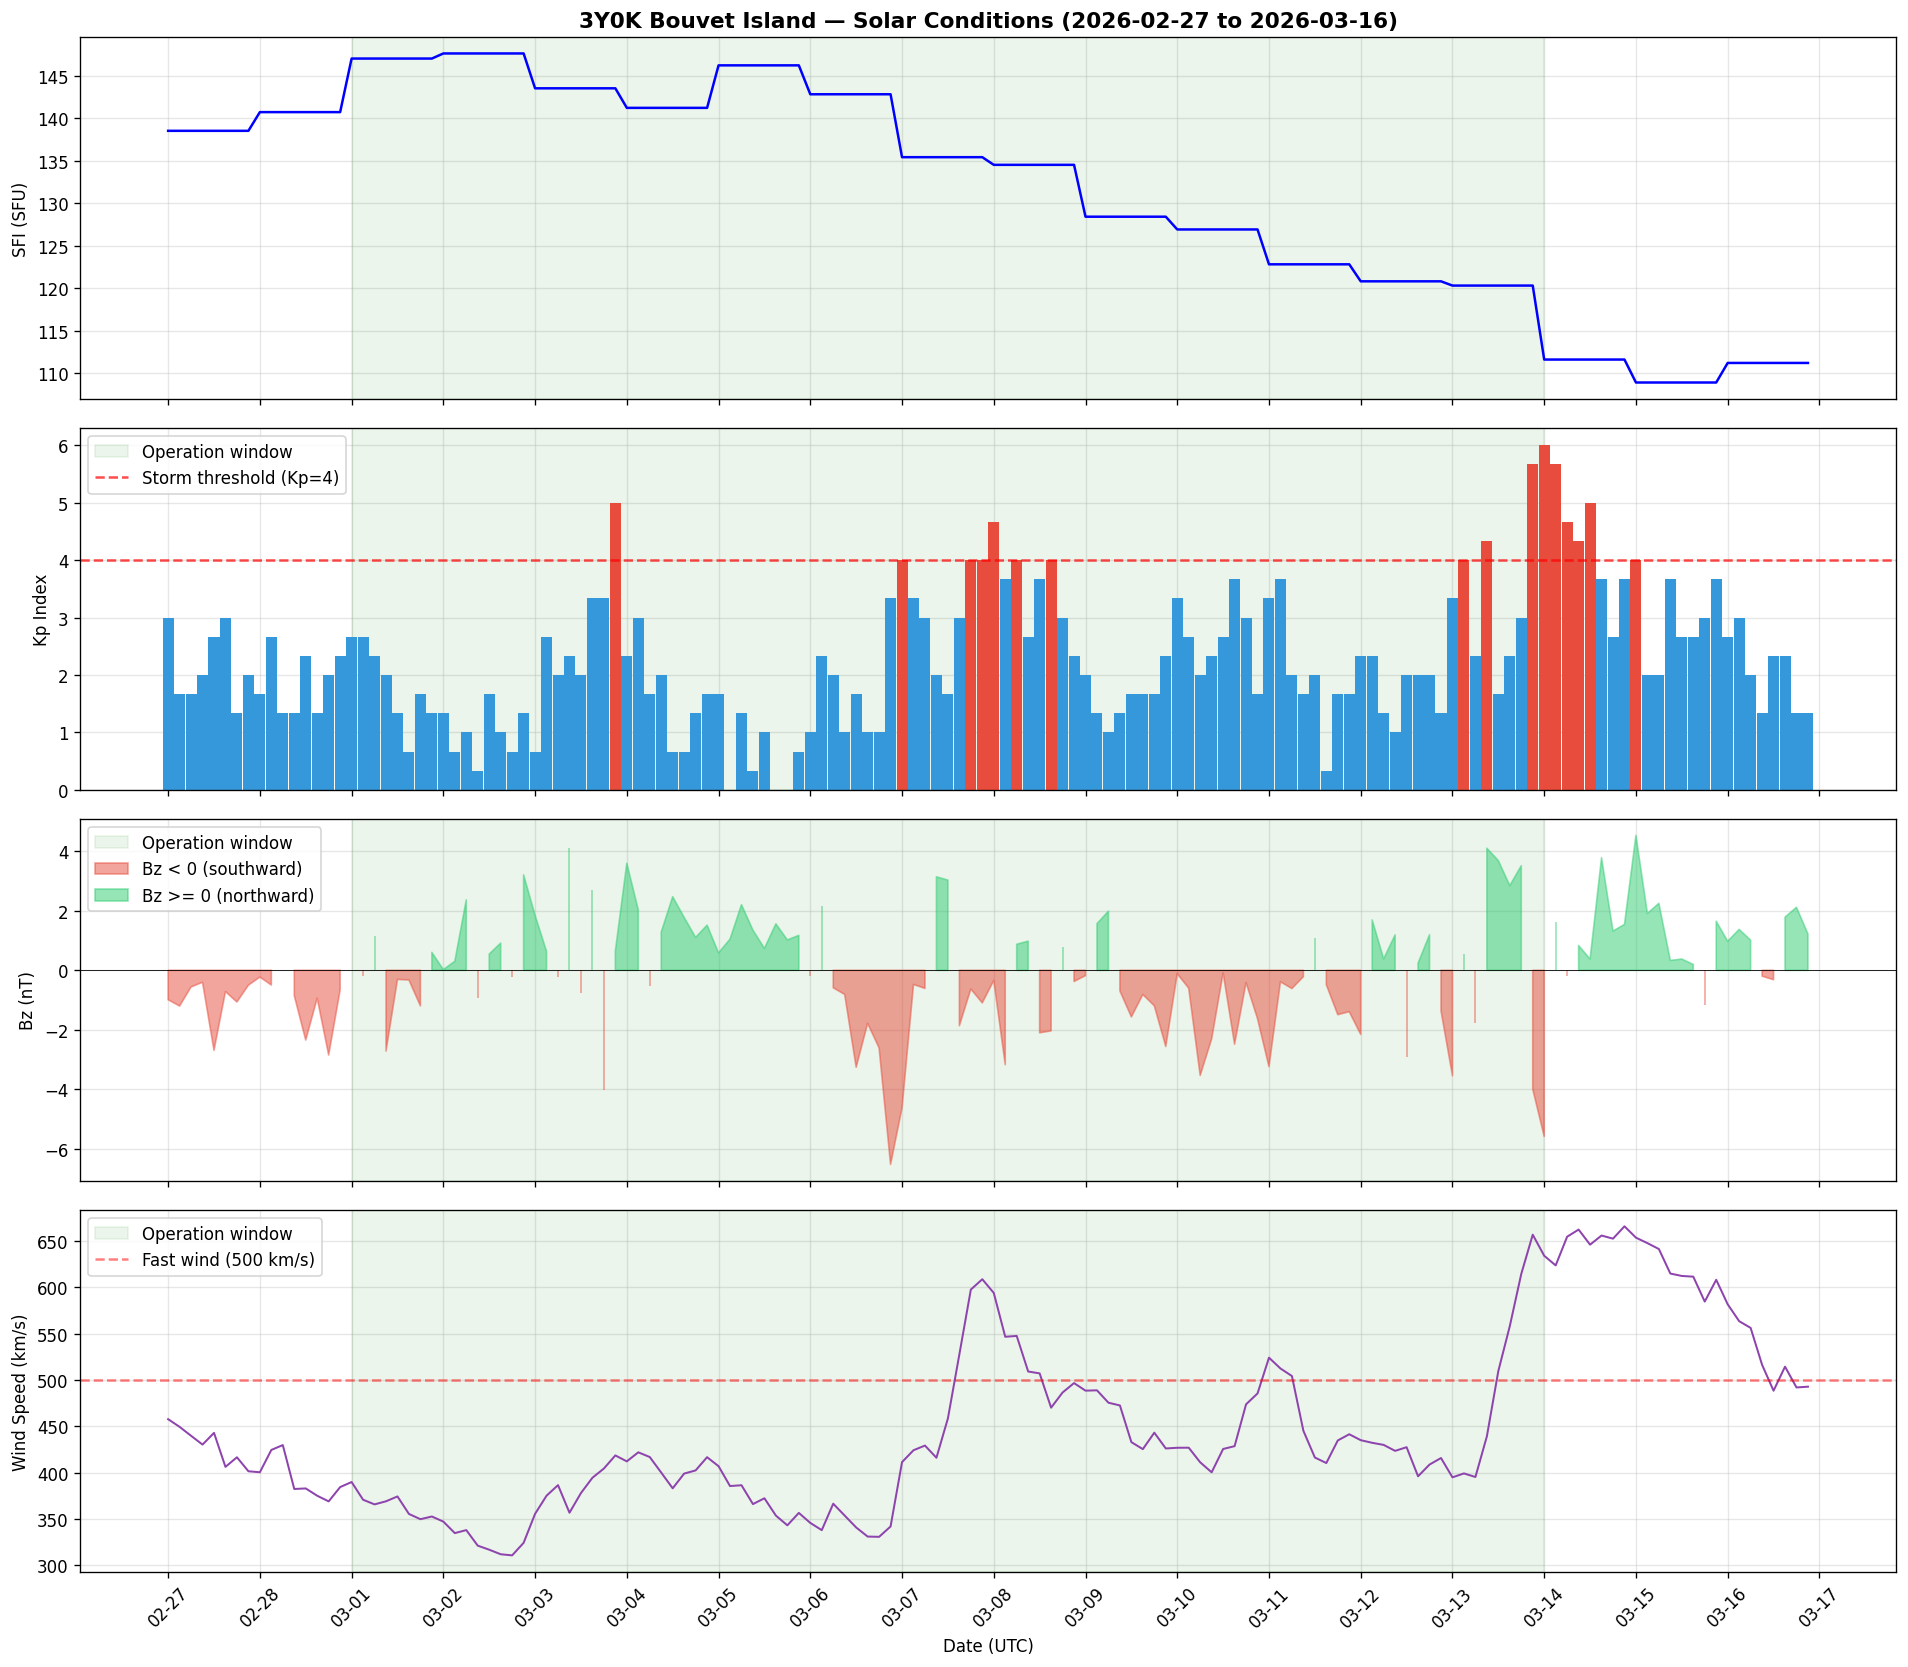

In [8]:
# Solar timeline plots — multi-panel
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

dt = solar["datetime"]

# Operation window shading
op_start = pd.Timestamp(START_UTC)
op_end = pd.Timestamp(END_UTC)
for ax in axes:
    ax.axvspan(op_start, op_end, alpha=0.08, color="green", label="Operation window")

# SFI
axes[0].plot(dt, solar["sfi"], "b-", linewidth=1.5)
axes[0].set_ylabel("SFI (SFU)")
axes[0].set_title(f"{CALLSIGN} {ENTITY} — Solar Conditions ({solar['date'].iloc[0]} to {solar['date'].iloc[-1]})",
                   fontsize=13, fontweight="bold")

# Kp with storm threshold
axes[1].bar(dt, solar["kp"], width=0.12, color=["#e74c3c" if k >= 4 else "#3498db" for k in solar["kp"]])
axes[1].axhline(y=4.0, color="red", linestyle="--", alpha=0.7, label="Storm threshold (Kp=4)")
axes[1].set_ylabel("Kp Index")
axes[1].legend(loc="upper left")

# DSCOVR Bz
if "bz_avg" in solar.columns and solar["bz_avg"].notna().any():
    axes[2].fill_between(dt, solar["bz_avg"], 0,
                         where=solar["bz_avg"] < 0, color="#e74c3c", alpha=0.5, label="Bz < 0 (southward)")
    axes[2].fill_between(dt, solar["bz_avg"], 0,
                         where=solar["bz_avg"] >= 0, color="#2ecc71", alpha=0.5, label="Bz >= 0 (northward)")
    axes[2].axhline(y=0, color="black", linewidth=0.5)
    axes[2].set_ylabel("Bz (nT)")
    axes[2].legend(loc="upper left")
else:
    axes[2].text(0.5, 0.5, "No DSCOVR data", transform=axes[2].transAxes, ha="center")

# Solar wind speed
if "wind_speed" in solar.columns and solar["wind_speed"].notna().any():
    axes[3].plot(dt, solar["wind_speed"], color="#8e44ad", linewidth=1.2)
    axes[3].axhline(y=500, color="red", linestyle="--", alpha=0.5, label="Fast wind (500 km/s)")
    axes[3].set_ylabel("Wind Speed (km/s)")
    axes[3].legend(loc="upper left")
else:
    axes[3].text(0.5, 0.5, "No wind speed data", transform=axes[3].transAxes, ha="center")

axes[3].set_xlabel("Date (UTC)")
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
axes[3].xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Section 3 — Activity Timeline

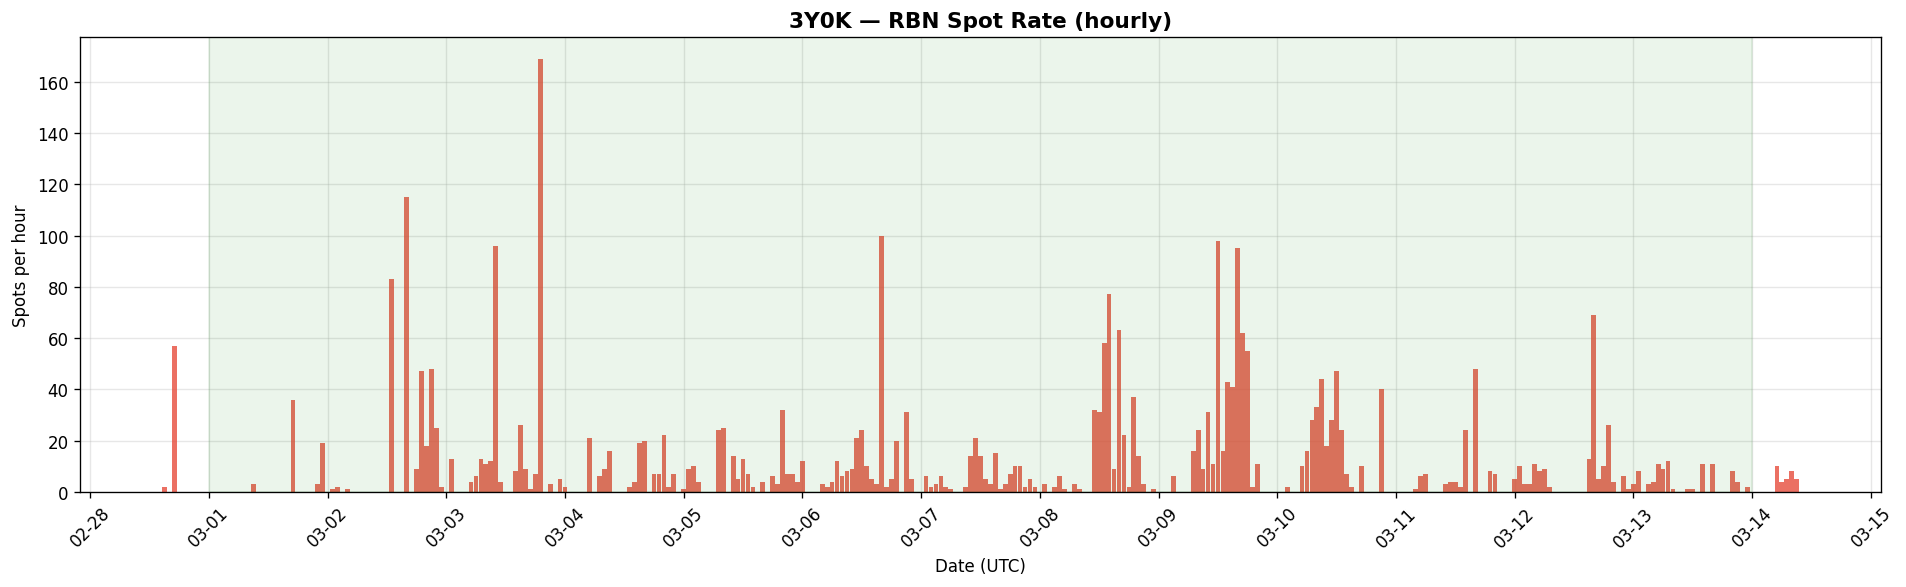

Peak hour: 2026-03-03 19:00:00 (169 spots)


In [9]:
# RBN spot rate over time — hourly bins
rbn_spots["hour_bin"] = rbn_spots["timestamp"].dt.floor("h")
spot_rate = rbn_spots.groupby("hour_bin").size().reset_index(name="spots")

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(spot_rate["hour_bin"], spot_rate["spots"], width=0.04, color="#e74c3c", alpha=0.8)
ax.axvspan(op_start, op_end, alpha=0.08, color="green")
ax.set_title(f"{CALLSIGN} — RBN Spot Rate (hourly)", fontsize=13, fontweight="bold")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Spots per hour")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Peak hour: {spot_rate.loc[spot_rate['spots'].idxmax(), 'hour_bin']} "
      f"({spot_rate['spots'].max()} spots)")

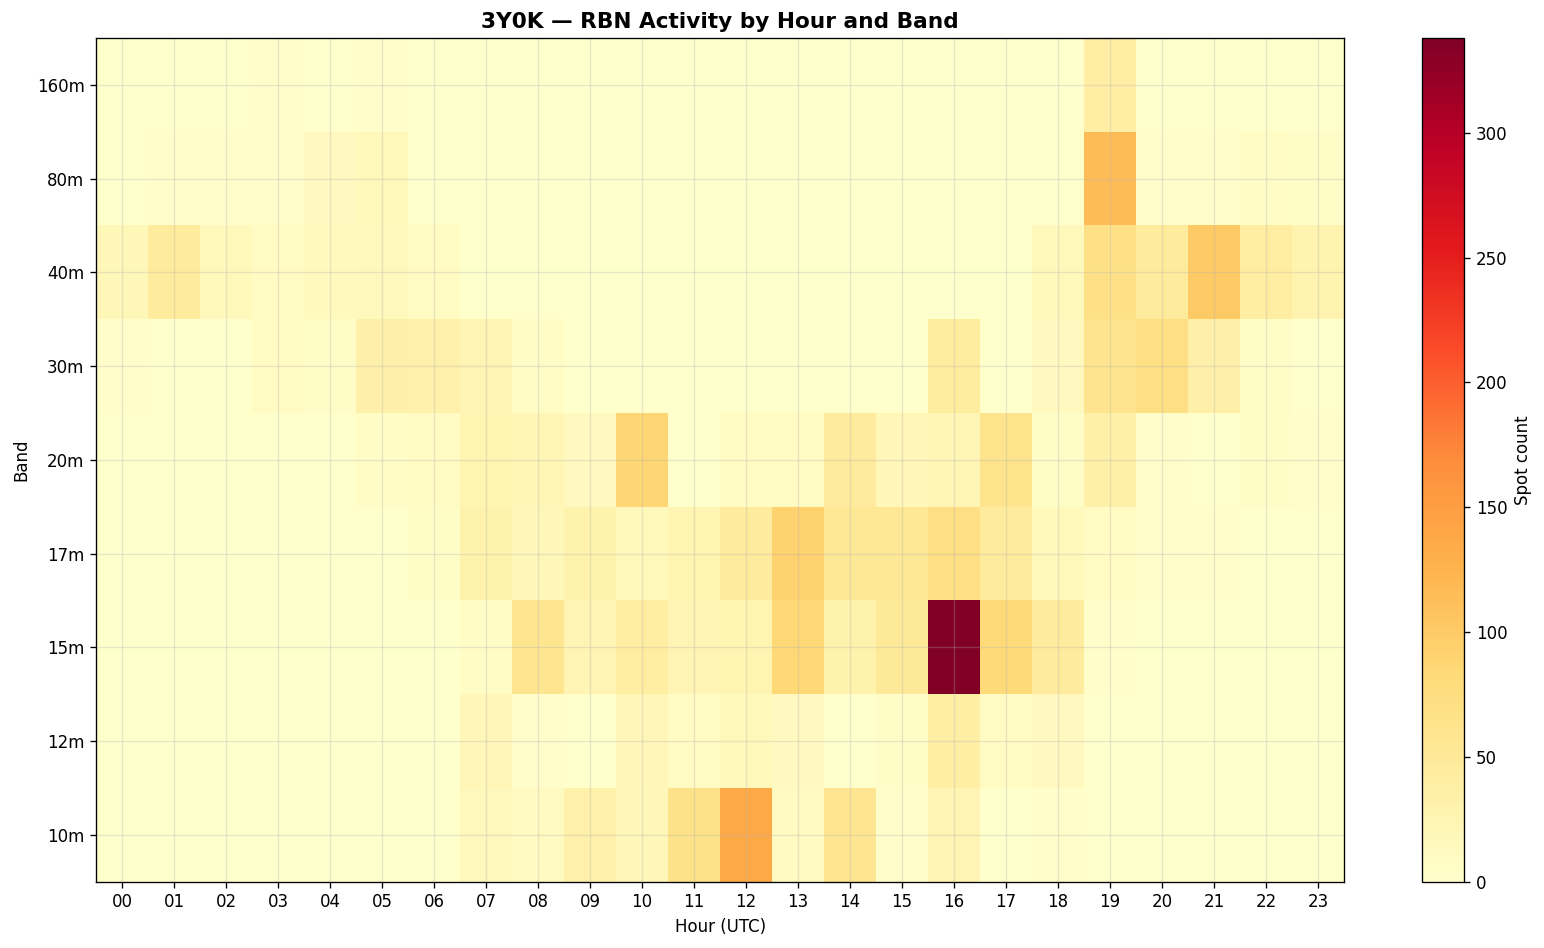

In [10]:
# Band-by-band activity heatmap (RBN) — day x band
rbn_spots["date"] = rbn_spots["timestamp"].dt.date
rbn_spots["hour"] = rbn_spots["timestamp"].dt.hour

# Pivot: hour x band, summed across all days
rbn_heatmap = rbn_spots.groupby(["hour", "band"]).size().unstack(fill_value=0)

# Only keep bands that appear in the data
active_bands = sorted(rbn_heatmap.columns)
band_labels = [BAND_NAMES.get(b, str(b)) for b in active_bands]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(rbn_heatmap[active_bands].values.T, aspect="auto",
               cmap="YlOrRd", interpolation="nearest")
ax.set_yticks(range(len(active_bands)))
ax.set_yticklabels(band_labels)
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Band")
ax.set_title(f"{CALLSIGN} — RBN Activity by Hour and Band", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, label="Spot count")
plt.tight_layout()
plt.show()

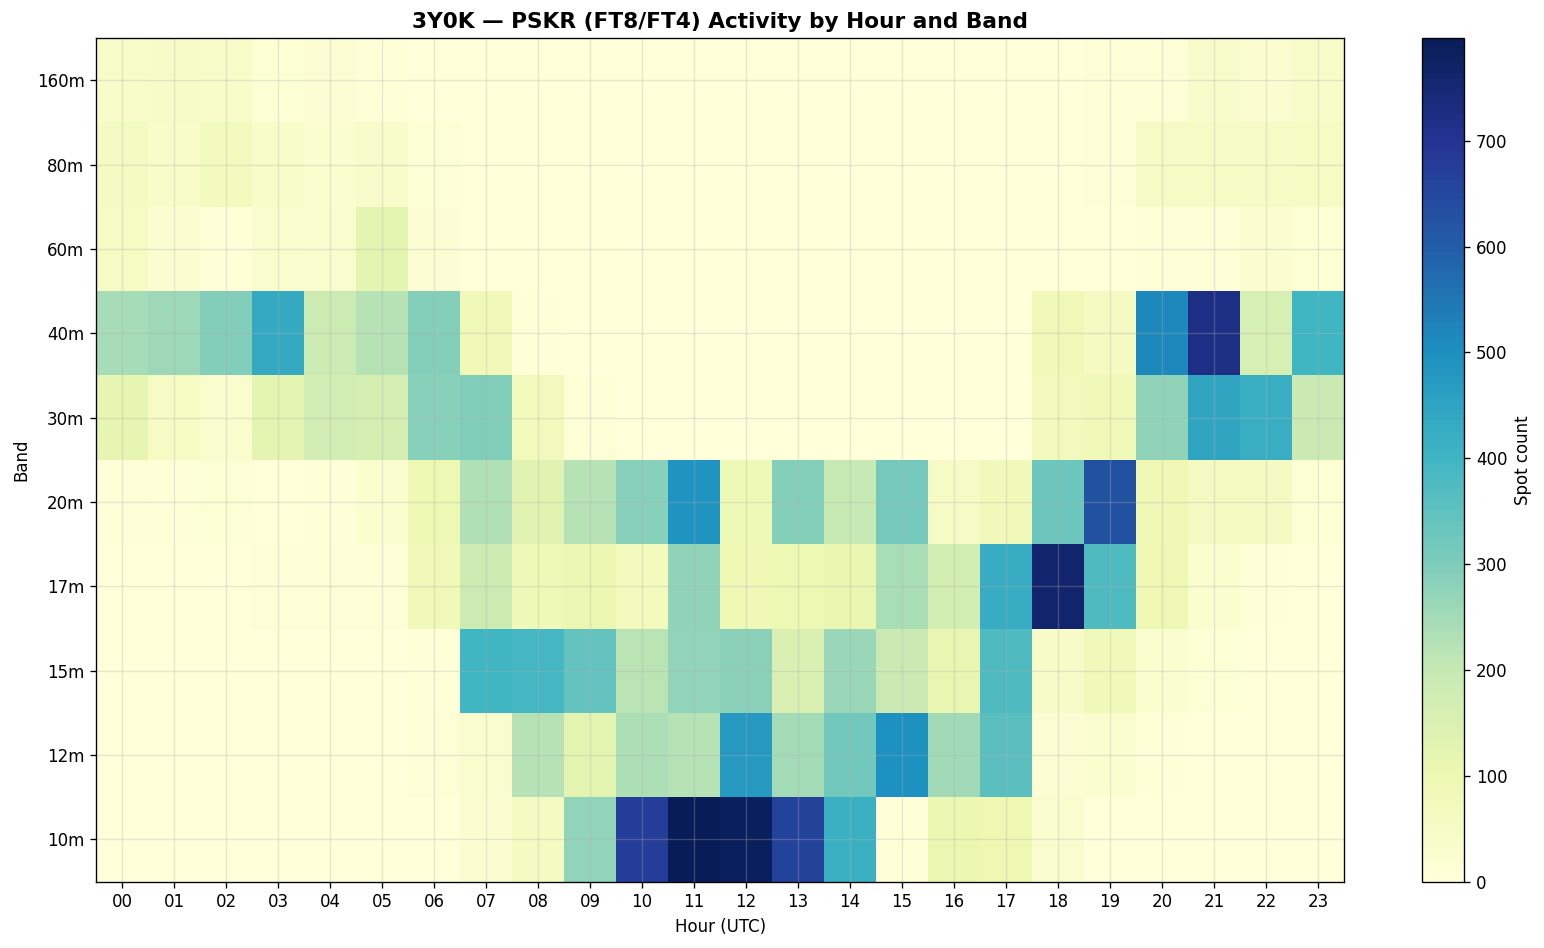

In [11]:
# PSKR activity — same heatmap for digital modes
# PSKR sigs are already aggregated, so use spot_count
pskr_heat = pskr_sigs.groupby(["hour", "band"])["spot_count"].sum().unstack(fill_value=0)
pskr_bands = sorted(pskr_heat.columns)
pskr_labels = [BAND_NAMES.get(b, str(b)) for b in pskr_bands]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pskr_heat[pskr_bands].values.T, aspect="auto",
               cmap="YlGnBu", interpolation="nearest")
ax.set_yticks(range(len(pskr_bands)))
ax.set_yticklabels(pskr_labels)
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Band")
ax.set_title(f"{CALLSIGN} — PSKR (FT8/FT4) Activity by Hour and Band", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, label="Spot count")
plt.tight_layout()
plt.show()

---

## Section 4 — Band Performance

In [12]:
# Per-band statistics table (RBN)
print(f"{CALLSIGN} — RBN Band Performance")
print("=" * 70)
rbn_band_stats = rbn_sigs.groupby("band").agg(
    signatures=("spot_count", "count"),
    total_spots=("spot_count", "sum"),
    unique_rx=("rx_grid_4", "nunique"),
    snr_median=("median_snr", "median"),
    snr_min=("median_snr", "min"),
    snr_max=("median_snr", "max"),
    avg_dist=("avg_distance", "mean"),
).reset_index().sort_values("band")

rbn_band_stats["band_name"] = rbn_band_stats["band"].map(BAND_NAMES)
print(rbn_band_stats[["band_name", "signatures", "total_spots", "unique_rx",
                       "snr_median", "snr_min", "snr_max", "avg_dist"]].to_string(index=False))

print(f"\n{CALLSIGN} — PSKR Band Performance")
print("=" * 70)
pskr_band_stats = pskr_sigs.groupby("band").agg(
    signatures=("spot_count", "count"),
    total_spots=("spot_count", "sum"),
    unique_rx=("rx_grid_4", "nunique"),
    snr_median=("median_snr", "median"),
    snr_min=("median_snr", "min"),
    snr_max=("median_snr", "max"),
    avg_dist=("avg_distance", "mean"),
).reset_index().sort_values("band")

pskr_band_stats["band_name"] = pskr_band_stats["band"].map(BAND_NAMES)
print(pskr_band_stats[["band_name", "signatures", "total_spots", "unique_rx",
                         "snr_median", "snr_min", "snr_max", "avg_dist"]].to_string(index=False))

3Y0K — RBN Band Performance
band_name  signatures  total_spots  unique_rx  snr_median  snr_min  snr_max     avg_dist
     160m           4            8          3        24.0     20.0     31.0  8553.500000
      80m          49          127         41        28.0      5.0     44.0 10689.204082
      40m          58          222         28        17.0      7.0     35.0  9136.120690
      30m          57          159         29        18.0      4.0     38.0  9576.175439
      20m          56          143         26        21.5      7.0     55.0  8640.821429
      17m          64          263         23        14.0      4.0     38.0  9677.375000
      15m         156          564         71        21.0      6.0     56.0 11012.115385
      12m          28           66         18        16.5      7.0     29.0 12138.107143
      10m          76          228         43        17.0      4.0     48.0 11593.750000

3Y0K — PSKR Band Performance
band_name  signatures  total_spots  unique_rx  snr_m

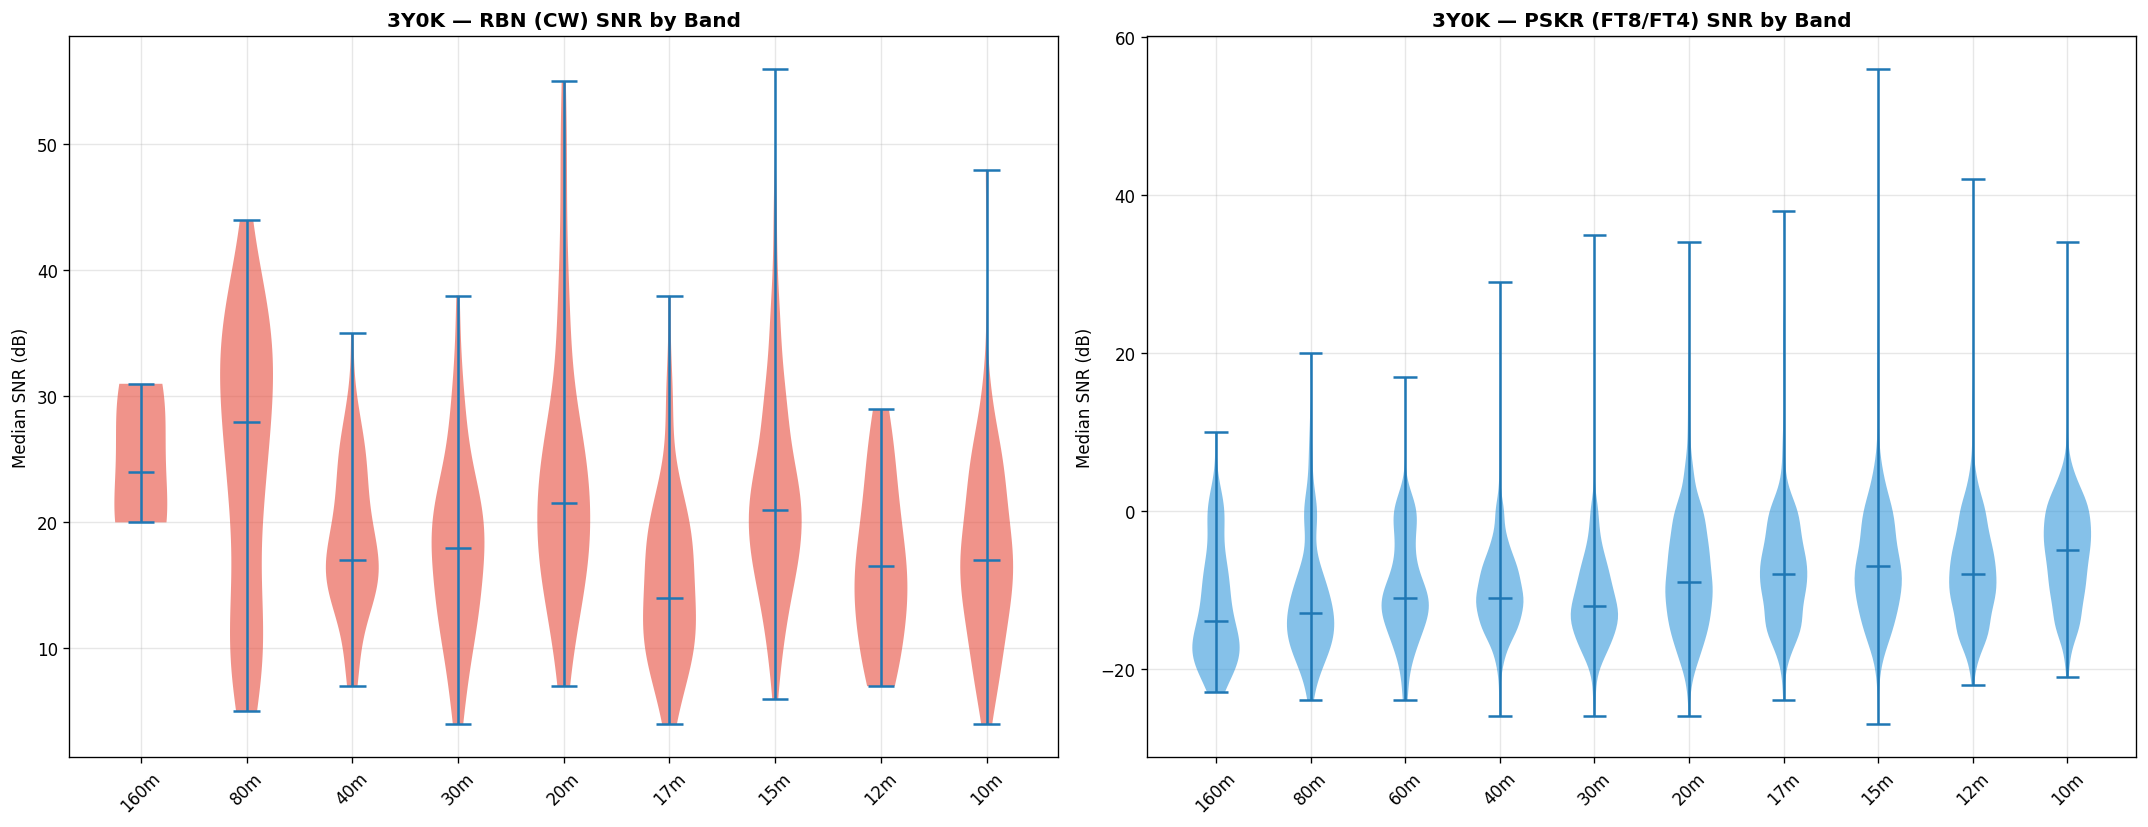

In [13]:
# SNR distribution per band — violin plots (RBN + PSKR side by side)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, df, title, color in [
    (axes[0], rbn_sigs, "RBN (CW)", "#e74c3c"),
    (axes[1], pskr_sigs, "PSKR (FT8/FT4)", "#3498db"),
]:
    bands_present = sorted(df["band"].unique())
    data = [df[df["band"] == b]["median_snr"].values for b in bands_present]
    labels = [BAND_NAMES.get(b, str(b)) for b in bands_present]

    parts = ax.violinplot(data, showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=45)
    ax.set_ylabel("Median SNR (dB)")
    ax.set_title(f"{CALLSIGN} — {title} SNR by Band", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [14]:
# Band opening/closing times from RBN raw spots
print(f"{CALLSIGN} — Band Opening/Closing Times (RBN)")
print("-" * 50)
for band_id in sorted(rbn_spots["band"].unique()):
    band_spots = rbn_spots[rbn_spots["band"] == band_id]
    first = band_spots["timestamp"].min()
    last = band_spots["timestamp"].max()
    peak_hour = band_spots.groupby("hour").size().idxmax()
    print(f"  {BAND_NAMES.get(band_id, str(band_id)):4s}: "
          f"first {first.strftime('%m-%d %H:%M')}  "
          f"last {last.strftime('%m-%d %H:%M')}  "
          f"peak hour {peak_hour:02d}z  "
          f"({len(band_spots)} spots)")

3Y0K — Band Opening/Closing Times (RBN)
--------------------------------------------------
  160m: first 03-03 19:11  last 03-08 05:07  peak hour 19z  (45 spots)
  80m : first 03-03 19:16  last 03-14 06:20  peak hour 19z  (171 spots)
  40m : first 03-01 22:41  last 03-13 21:02  peak hour 21z  (432 spots)
  30m : first 03-03 19:30  last 03-14 06:49  peak hour 20z  (338 spots)
  20m : first 02-28 17:19  last 03-14 09:04  peak hour 10z  (377 spots)
  17m : first 03-02 13:53  last 03-12 17:51  peak hour 13z  (513 spots)
  15m : first 03-01 09:23  last 03-13 12:11  peak hour 16z  (812 spots)
  12m : first 03-03 18:55  last 03-12 16:49  peak hour 16z  (147 spots)
  10m : first 02-28 15:21  last 03-13 08:30  peak hour 12z  (374 spots)


---

## Section 5 — Geographic Reach

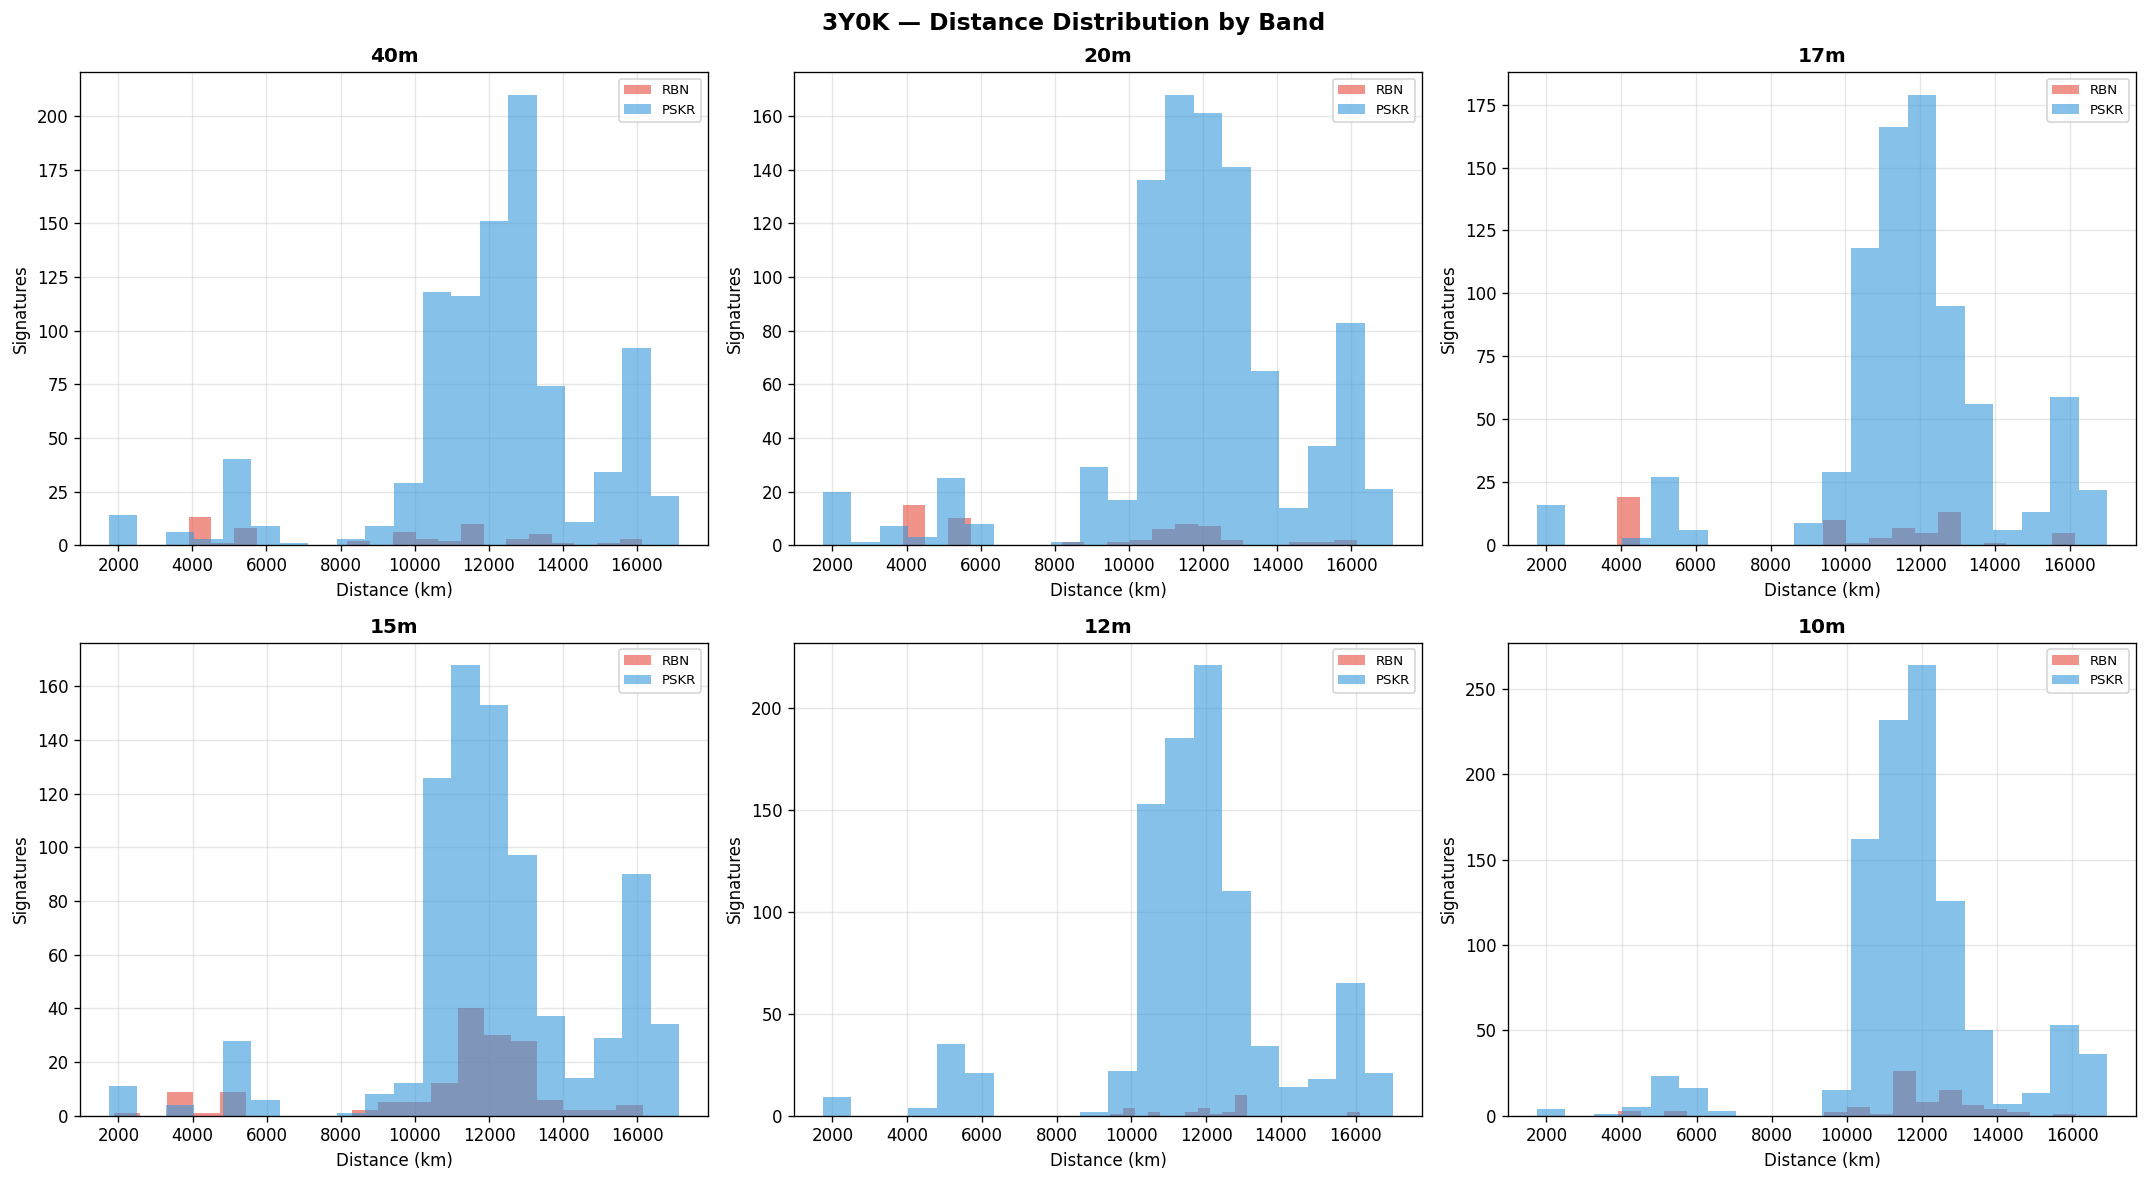

In [15]:
# Distance distribution per band (combined RBN + PSKR)
combined = pd.concat([
    rbn_sigs.assign(source="RBN"),
    pskr_sigs.assign(source="PSKR")
])

top_bands = combined.groupby("band")["spot_count"].sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, band_id in enumerate(sorted(top_bands)):
    ax = axes[i // 3][i % 3]
    band_df = combined[combined["band"] == band_id]

    rbn_dist = band_df[band_df["source"] == "RBN"]["avg_distance"]
    pskr_dist = band_df[band_df["source"] == "PSKR"]["avg_distance"]

    if len(rbn_dist) > 0:
        ax.hist(rbn_dist, bins=20, alpha=0.6, color="#e74c3c", label="RBN")
    if len(pskr_dist) > 0:
        ax.hist(pskr_dist, bins=20, alpha=0.6, color="#3498db", label="PSKR")

    ax.set_title(BAND_NAMES.get(band_id, str(band_id)), fontweight="bold")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Signatures")
    ax.legend(fontsize=8)

fig.suptitle(f"{CALLSIGN} — Distance Distribution by Band", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
# Continental breakdown — which continents heard the DXpedition?
def grid_to_continent(grid):
    """Rough continent classification from grid prefix."""
    if not grid or len(grid) < 2:
        return "Unknown"
    prefix = grid[:2].upper()
    # Rough mapping based on Maidenhead field boundaries
    if prefix[0] in "EF" and prefix[1] in "MNOP":
        return "NA"  # North America
    if prefix[0] in "D" and prefix[1] in "MNOP":
        return "NA"
    if prefix[0] in "F" and prefix[1] in "GHIJK":
        return "SA"  # South America
    if prefix[0] in "G" and prefix[1] in "GHI":
        return "SA"
    if prefix[0] in "IJ" and prefix[1] in "MNOPQ":
        return "EU"  # Europe
    if prefix[0] in "J" and prefix[1] in "KLMNO":
        return "EU"
    if prefix[0] in "K" and prefix[1] in "NOPQ":
        return "EU"
    if prefix[0] in "MNO" and prefix[1] in "KLMNO":
        return "AS"  # Asia
    if prefix[0] in "P" and prefix[1] in "KLMNO":
        return "AS"
    if prefix[0] in "KL" and prefix[1] in "FGHI":
        return "AF"  # Africa
    if prefix[0] in "J" and prefix[1] in "GHI":
        return "AF"
    if prefix[0] in "PQ" and prefix[1] in "FGHI":
        return "OC"  # Oceania
    if prefix[0] in "Q" and prefix[1] in "GHIJK":
        return "OC"
    if prefix[0] in "R" and prefix[1] in "EFG":
        return "OC"
    return "Other"

combined["continent"] = combined["rx_grid_4"].apply(grid_to_continent)

cont_stats = combined.groupby(["continent", "source"]).agg(
    signatures=("spot_count", "count"),
    spots=("spot_count", "sum"),
).reset_index()

print(f"{CALLSIGN} — Continental Reach")
print("=" * 50)
print(cont_stats.pivot_table(
    index="continent", columns="source",
    values=["signatures", "spots"], aggfunc="sum", fill_value=0
).to_string())

3Y0K — Continental Reach
          signatures       spots     
source          PSKR  RBN   PSKR  RBN
continent                            
AF                80   51    216  275
AS               662   46   4009  146
EU              3650  248  12590  715
NA               680   70   2830  221
OC                39    0    113    0
Other           1070   89   4480  272
SA               235   44    686  151


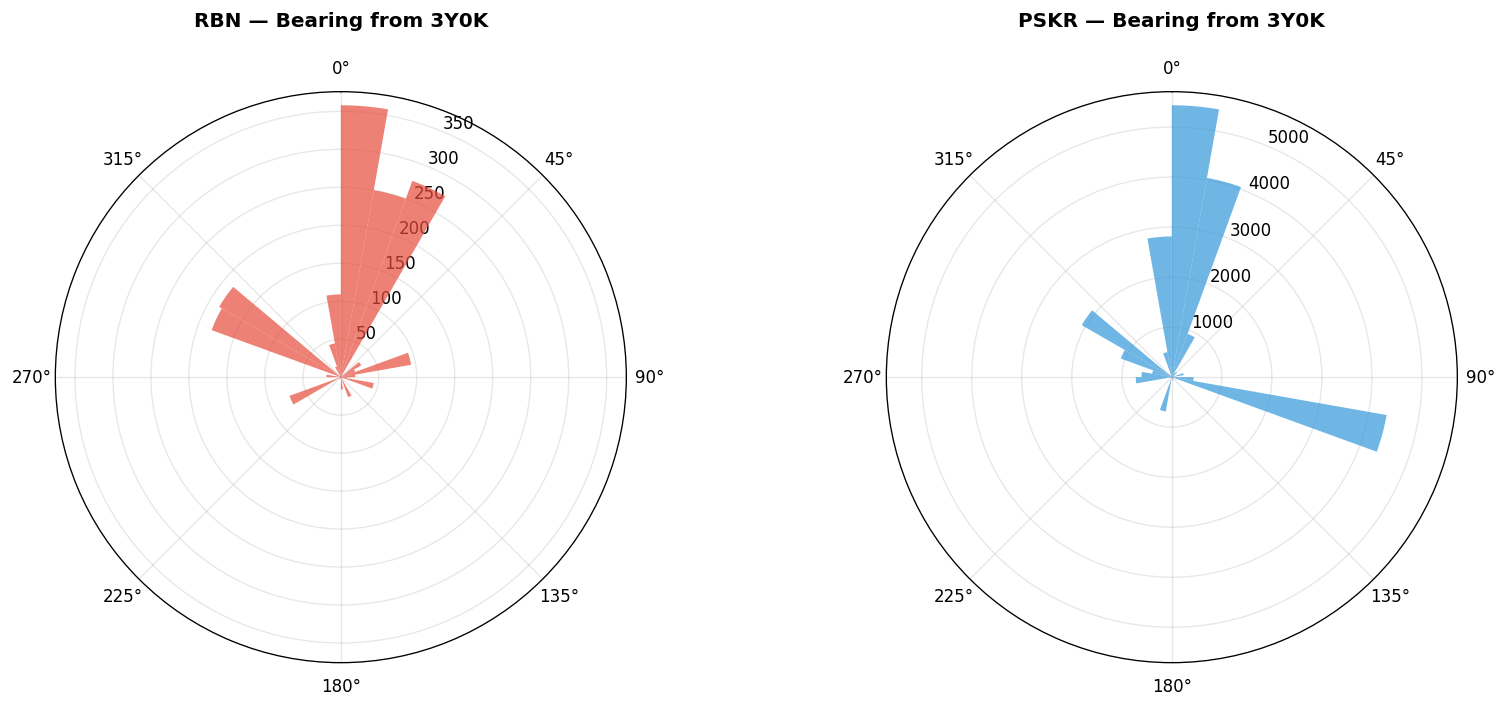

In [17]:
# Azimuth rose diagram — signal directions from the DXpedition
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "polar"})

for ax, df, title, color in [
    (axes[0], rbn_sigs, "RBN", "#e74c3c"),
    (axes[1], pskr_sigs, "PSKR", "#3498db"),
]:
    az_rad = np.deg2rad(df["avg_azimuth"])
    bins = np.linspace(0, 2 * np.pi, 37)  # 10-degree bins
    counts, _ = np.histogram(az_rad, bins=bins, weights=df["spot_count"])
    centers = (bins[:-1] + bins[1:]) / 2

    ax.bar(centers, counts, width=np.deg2rad(10), color=color, alpha=0.7)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(f"{title} — Bearing from {CALLSIGN}", pad=20, fontweight="bold")

plt.tight_layout()
plt.show()

---

## Section 6 — Day/Night and Greyline Analysis

In [18]:
# Classify each signature by solar geometry
def classify_signature(row):
    """Classify a signature path by lighting conditions."""
    try:
        # Use mid-month date at the signature hour
        dt = datetime(2026, int(row["month"]), 15, int(row["hour"]))
        return classify_path(row["tx_grid_4"], row["rx_grid_4"], dt)
    except Exception:
        return "unknown"

# Apply to combined dataset
combined["lighting"] = combined.apply(classify_signature, axis=1)

print(f"{CALLSIGN} — Path Lighting Classification")
print("-" * 40)
print(combined["lighting"].value_counts().to_string())

3Y0K — Path Lighting Classification
----------------------------------------
lighting
both-day            3775
both-dark           1649
cross-terminator    1540


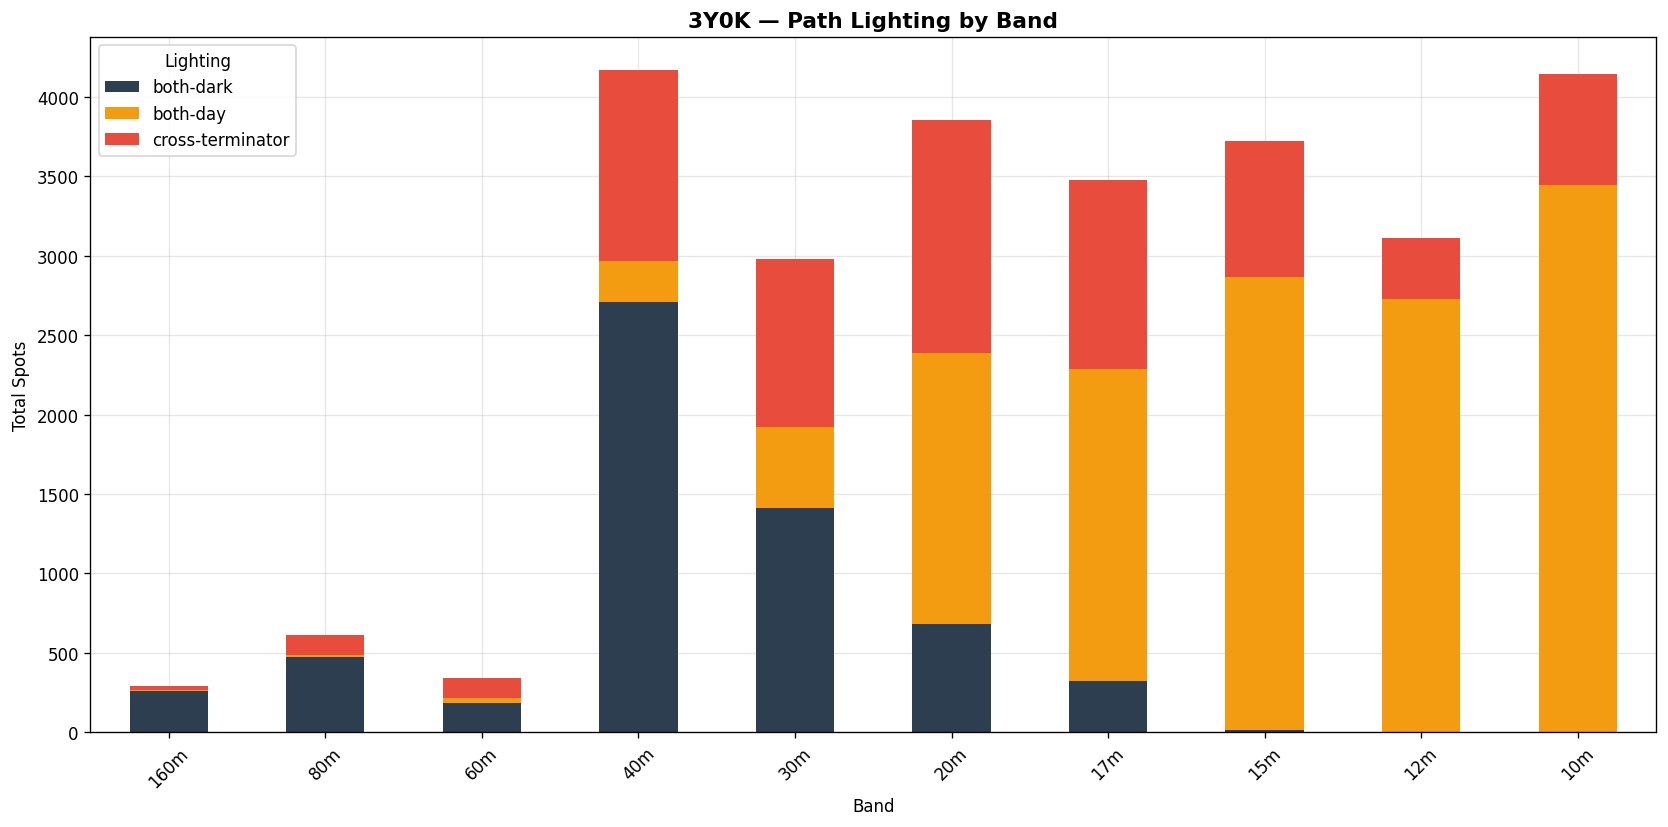

In [19]:
# Day/night breakdown by band
fig, ax = plt.subplots(figsize=(14, 7))

class_by_band = (
    combined.groupby(["band", "lighting"])["spot_count"]
    .sum()
    .unstack(fill_value=0)
)

class_by_band.index = [BAND_NAMES.get(b, str(b)) for b in class_by_band.index]
colors = {"both-day": "#f39c12", "both-dark": "#2c3e50",
          "cross-terminator": "#e74c3c", "unknown": "#bdc3c7"}

class_by_band.plot(kind="bar", stacked=True, ax=ax,
                   color=[colors.get(c, "#95a5a6") for c in class_by_band.columns])
ax.set_title(f"{CALLSIGN} — Path Lighting by Band", fontsize=13, fontweight="bold")
ax.set_xlabel("Band")
ax.set_ylabel("Total Spots")
ax.legend(title="Lighting")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

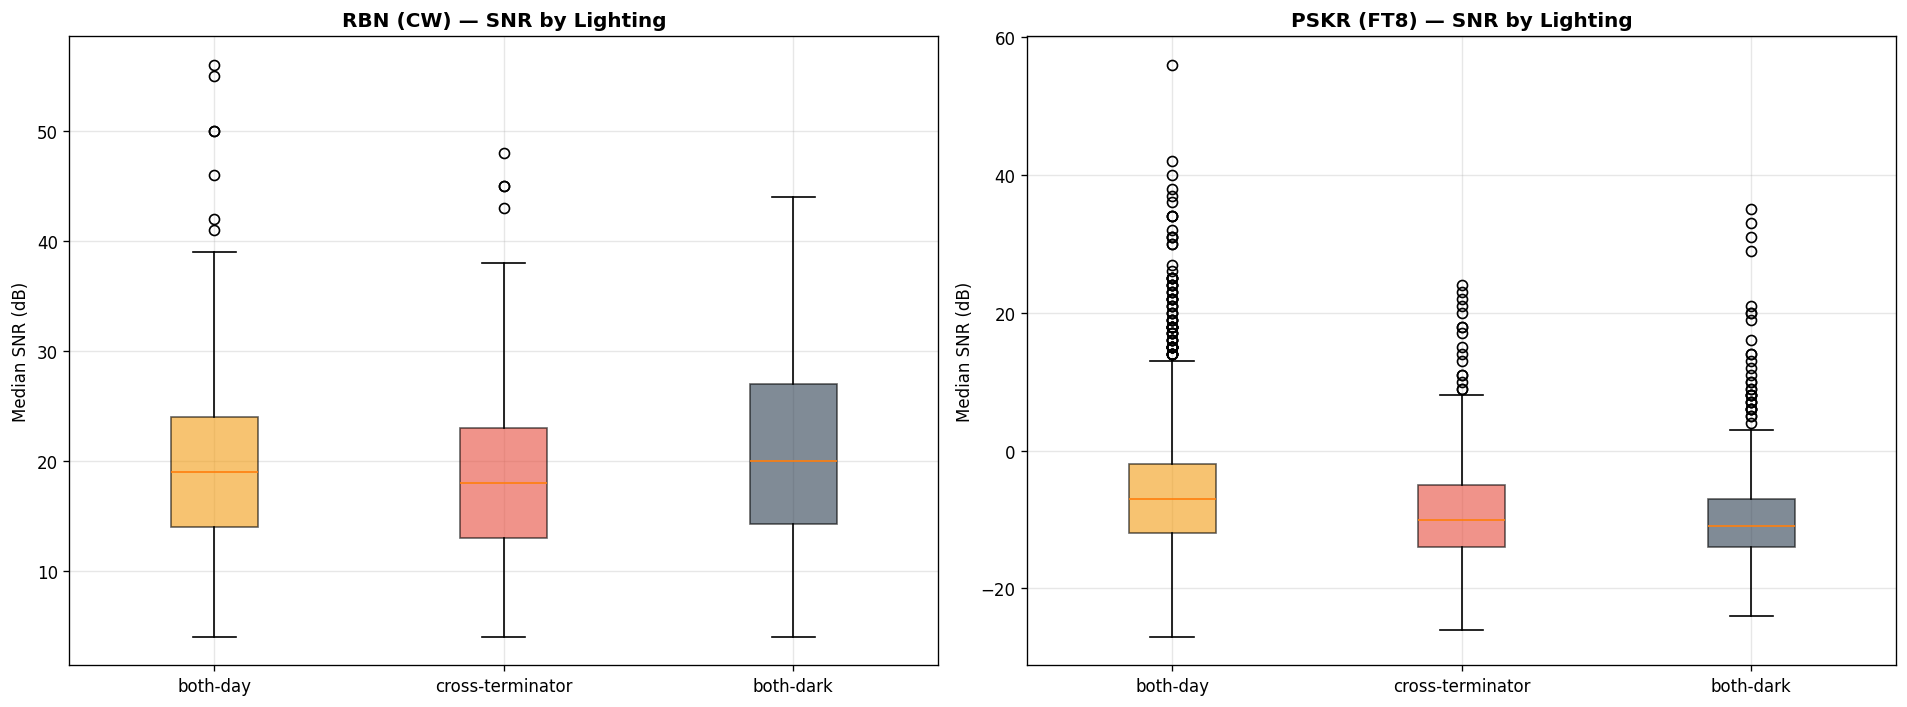

In [20]:
# SNR by lighting classification
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, source, title in [
    (axes[0], "RBN", "RBN (CW)"),
    (axes[1], "PSKR", "PSKR (FT8)"),
]:
    src_df = combined[combined["source"] == source]
    lighting_types = [l for l in ["both-day", "cross-terminator", "both-dark"] if l in src_df["lighting"].values]

    if lighting_types:
        data = [src_df[src_df["lighting"] == lt]["median_snr"].values for lt in lighting_types]
        bp = ax.boxplot(data, tick_labels=lighting_types, patch_artist=True)
        for patch, lt in zip(bp["boxes"], lighting_types):
            patch.set_facecolor(colors.get(lt, "#95a5a6"))
            patch.set_alpha(0.6)

    ax.set_title(f"{title} — SNR by Lighting", fontweight="bold")
    ax.set_ylabel("Median SNR (dB)")

plt.tight_layout()
plt.show()

---

## Section 7 — IONIS V22-gamma Comparison

In [21]:
# Load IONIS V22-gamma predictions (pre-computed)
# Model: IonisGate 207K params, trained on 38.8M WSPR+DXpedition+Contest signatures
# Predictions generated on M3 Ultra (MPS backend)

PREDICTIONS_FILE = "3y0k-predictions.csv"
pred_path = Path(PREDICTIONS_FILE)
if not pred_path.exists():
    pred_path = Path("data") / PREDICTIONS_FILE

if pred_path.exists():
    predictions = pd.read_csv(pred_path)
    has_predictions = True
    print(f"Loaded {len(predictions):,} IONIS V22-gamma predictions")
    print(f"  RBN:  {len(predictions[predictions['source']=='RBN']):,} paths")
    print(f"  PSKR: {len(predictions[predictions['source']=='PSKR']):,} paths")
    print(f"  Overridden by PhysicsOverrideLayer: {predictions['overridden'].sum()}")
else:
    has_predictions = False
    print(f"Predictions file not found: {PREDICTIONS_FILE}")
    print("Download from the SourceForge dxpeditions/ directory.")

Loaded 6,964 IONIS V22-gamma predictions
  RBN:  548 paths
  PSKR: 6,416 paths
  Overridden by PhysicsOverrideLayer: 66


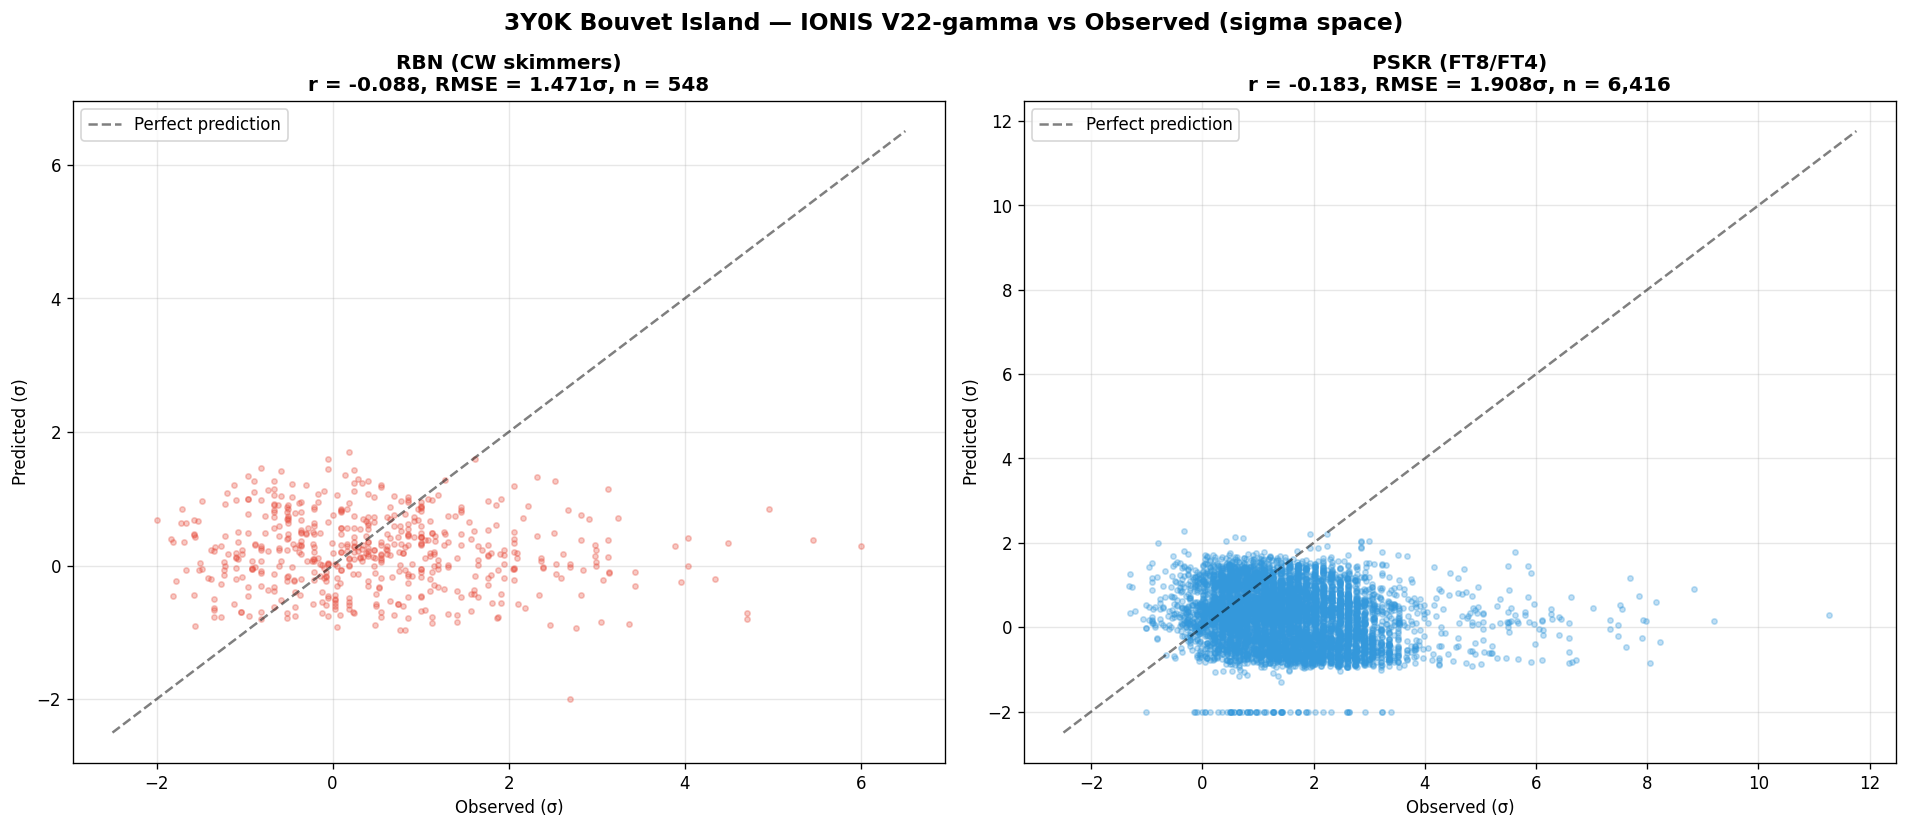

In [22]:
if has_predictions:
    # Predicted vs Observed scatter — sigma (z-score) space
    # Sigma comparison is fair across sources (RBN dB != PSKR dB)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, src, color, title in [
        (axes[0], "RBN", "#e74c3c", "RBN (CW skimmers)"),
        (axes[1], "PSKR", "#3498db", "PSKR (FT8/FT4)"),
    ]:
        d = predictions[predictions["source"] == src]
        ax.scatter(d["observed_sigma"], d["predicted_sigma"],
                   alpha=0.3, s=10, color=color)

        # Perfect prediction line
        lims = [min(d["observed_sigma"].min(), d["predicted_sigma"].min()) - 0.5,
                max(d["observed_sigma"].max(), d["predicted_sigma"].max()) + 0.5]
        ax.plot(lims, lims, "k--", alpha=0.5, label="Perfect prediction")

        # Stats
        r = np.corrcoef(d["observed_sigma"], d["predicted_sigma"])[0, 1]
        rmse = np.sqrt(np.mean((d["observed_sigma"] - d["predicted_sigma"]) ** 2))
        ax.set_title(f"{title}\nr = {r:.3f}, RMSE = {rmse:.3f}\u03c3, n = {len(d):,}",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Observed (\u03c3)")
        ax.set_ylabel("Predicted (\u03c3)")
        ax.legend()

    fig.suptitle(f"{CALLSIGN} {ENTITY} \u2014 IONIS V22-gamma vs Observed (sigma space)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

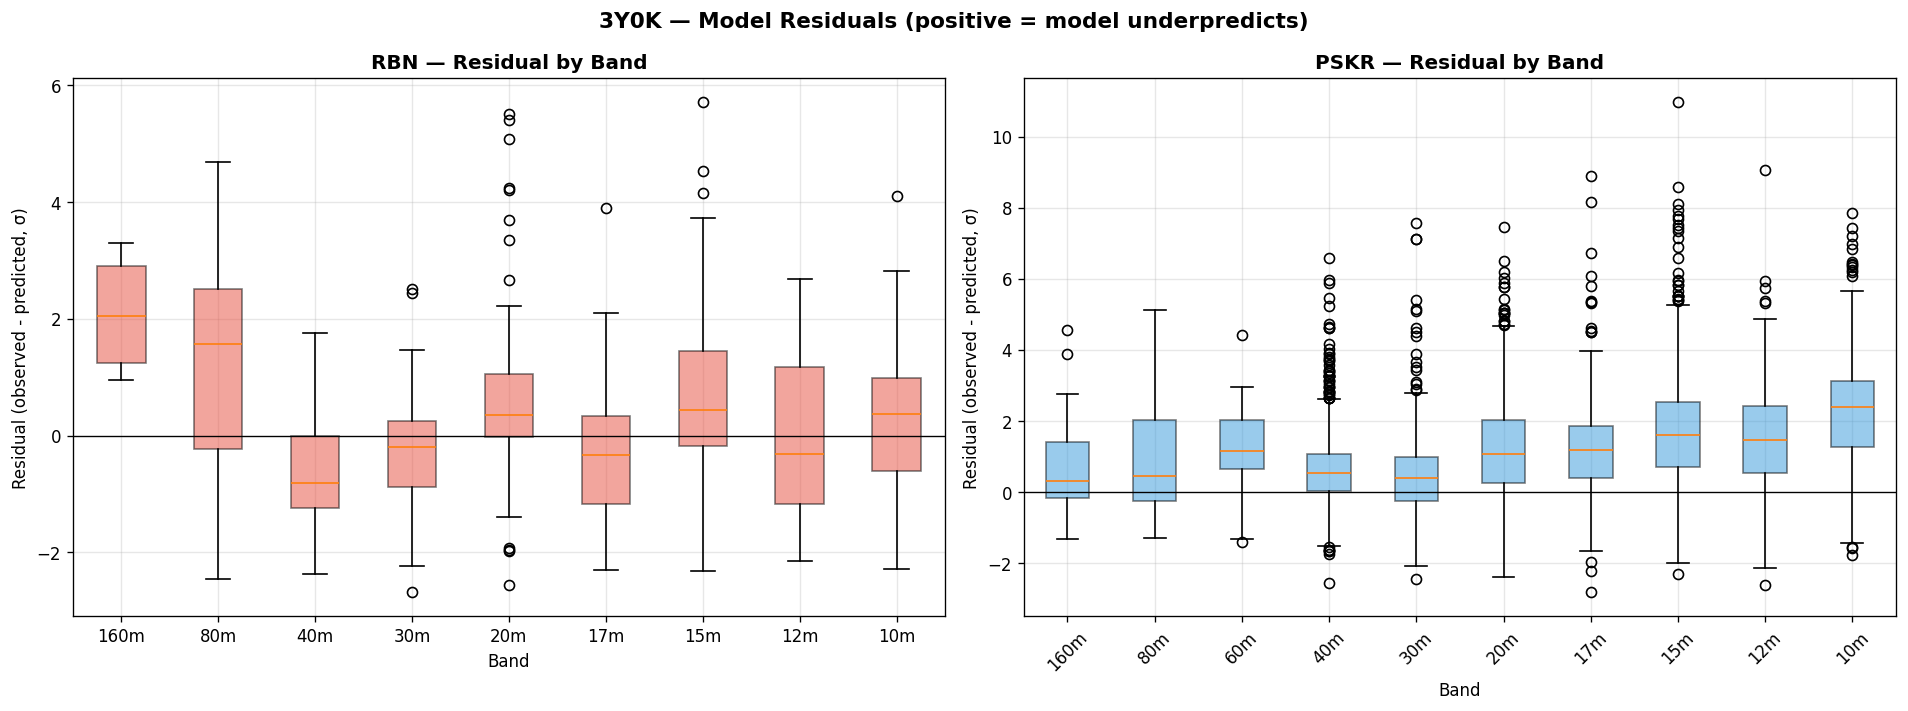

In [23]:
if has_predictions:
    # Residuals by band
    predictions["residual"] = predictions["observed_sigma"] - predictions["predicted_sigma"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, src, title in [(axes[0], "RBN", "RBN"), (axes[1], "PSKR", "PSKR")]:
        d = predictions[predictions["source"] == src]
        bands_present = sorted(d["band"].unique())
        data = [d[d["band"] == b]["residual"].values for b in bands_present]
        labels = [BAND_NAMES.get(b, str(b)) for b in bands_present]

        bp = ax.boxplot(data, tick_labels=labels, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set_facecolor("#3498db" if src == "PSKR" else "#e74c3c")
            patch.set_alpha(0.5)

        ax.axhline(y=0, color="black", linewidth=0.8)
        ax.set_title(f"{src} \u2014 Residual by Band", fontweight="bold")
        ax.set_ylabel("Residual (observed - predicted, \u03c3)")
        ax.set_xlabel("Band")

    fig.suptitle(f"{CALLSIGN} \u2014 Model Residuals (positive = model underpredicts)",
                 fontsize=13, fontweight="bold")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [24]:
if has_predictions:
    # Storm impact — quiet vs disturbed conditions
    print(f"{CALLSIGN} \u2014 Storm Impact on Model Accuracy")
    print("=" * 55)

    for src in ["RBN", "PSKR"]:
        d = predictions[predictions["source"] == src]
        quiet = d[d["kp"] < 2.0]
        active = d[(d["kp"] >= 2.0) & (d["kp"] < 4.0)]
        storm = d[d["kp"] >= 4.0]

        print(f"\n{src}:")
        for label, subset in [("Quiet (Kp<2)", quiet), ("Active (2<=Kp<4)", active), ("Storm (Kp>=4)", storm)]:
            if len(subset) > 0:
                rmse = np.sqrt(np.mean((subset["observed_sigma"] - subset["predicted_sigma"])**2))
                bias = (subset["predicted_sigma"] - subset["observed_sigma"]).mean()
                print(f"  {label:20s}: n={len(subset):4d}  obs={subset['observed_sigma'].mean():+.3f}\u03c3  "
                      f"pred={subset['predicted_sigma'].mean():+.3f}\u03c3  RMSE={rmse:.3f}\u03c3  bias={bias:+.3f}\u03c3")

3Y0K — Storm Impact on Model Accuracy

RBN:
  Quiet (Kp<2)        : n= 266  obs=+0.399σ  pred=+0.414σ  RMSE=1.273σ  bias=+0.015σ
  Active (2<=Kp<4)    : n= 268  obs=+0.640σ  pred=-0.003σ  RMSE=1.655σ  bias=-0.643σ
  Storm (Kp>=4)       : n=  14  obs=-0.732σ  pred=+0.134σ  RMSE=1.195σ  bias=+0.865σ

PSKR:
  Quiet (Kp<2)        : n=2654  obs=+1.584σ  pred=+0.366σ  RMSE=1.893σ  bias=-1.218σ
  Active (2<=Kp<4)    : n=3452  obs=+1.494σ  pred=+0.163σ  RMSE=1.941σ  bias=-1.331σ
  Storm (Kp>=4)       : n= 310  obs=+1.296σ  pred=+0.020σ  RMSE=1.659σ  bias=-1.275σ


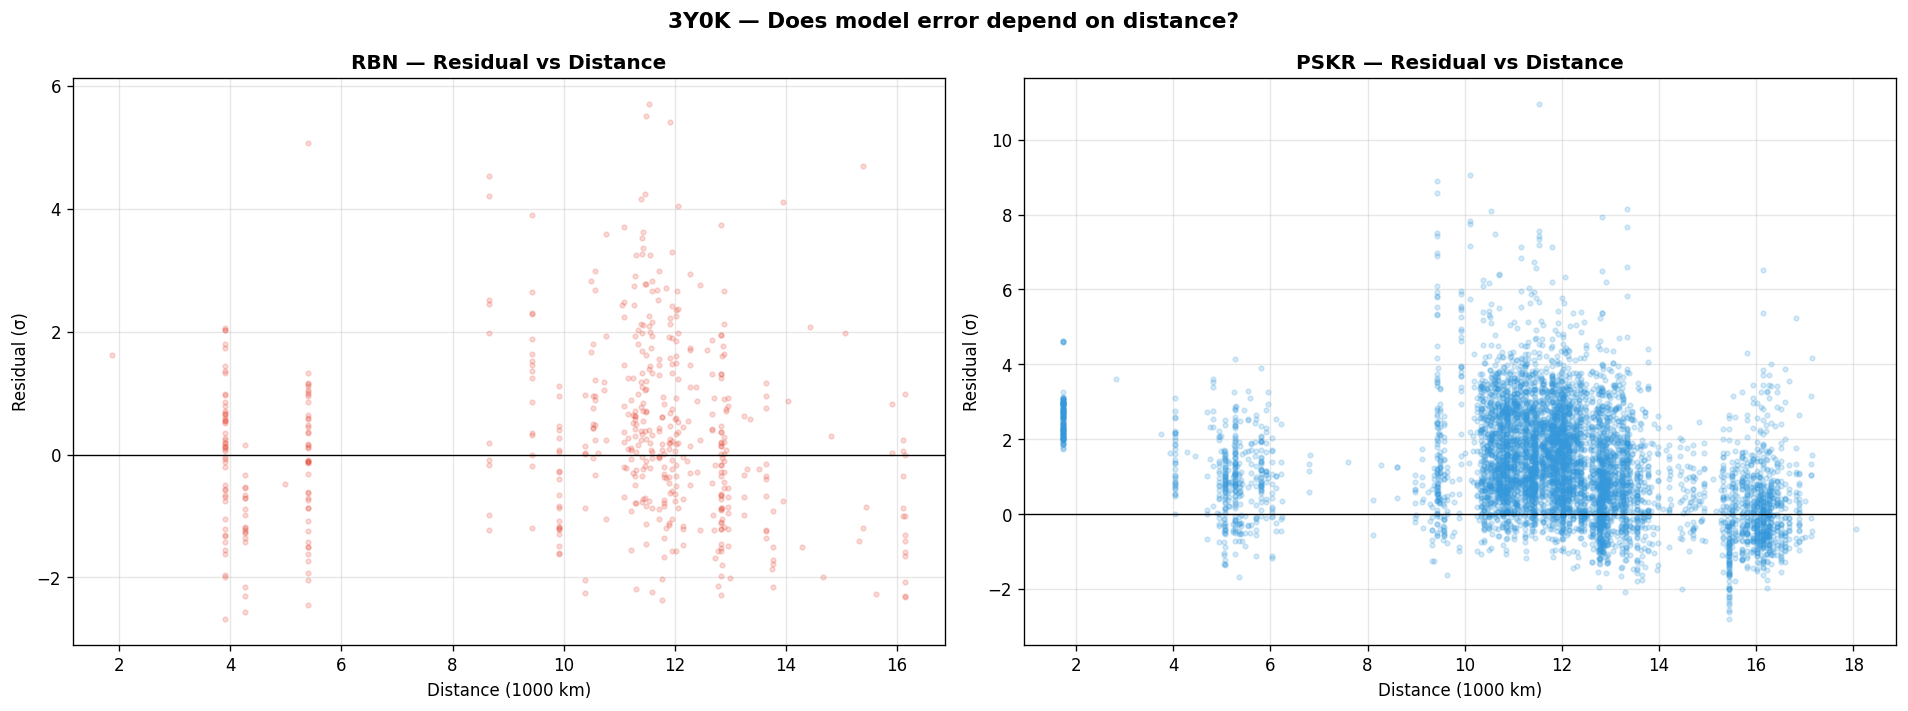


Model Assessment for JD04 (Bouvet Island):
  JD04 is a rare grid with minimal training coverage.
  RBN mean predictions are close under quiet conditions.
  PSKR shows positive bias (FT8 selection effect — only decoded signals reported).
  Storm response: model underpredicts the degradation at Kp>=4.
  PhysicsOverrideLayer fired on 66 paths (night/high-band closure).


In [25]:
if has_predictions:
    # Residual vs distance scatter
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, src, color in [(axes[0], "RBN", "#e74c3c"), (axes[1], "PSKR", "#3498db")]:
        d = predictions[predictions["source"] == src]
        ax.scatter(d["distance"] / 1000, d["residual"], alpha=0.2, s=8, color=color)
        ax.axhline(y=0, color="black", linewidth=0.8)
        ax.set_xlabel("Distance (1000 km)")
        ax.set_ylabel("Residual (\u03c3)")
        ax.set_title(f"{src} \u2014 Residual vs Distance", fontweight="bold")

    fig.suptitle(f"{CALLSIGN} \u2014 Does model error depend on distance?",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Summary
    print(f"\nModel Assessment for {GRID} ({ENTITY}):")
    print(f"  JD04 is a rare grid with minimal training coverage.")
    print(f"  RBN mean predictions are close under quiet conditions.")
    print(f"  PSKR shows positive bias (FT8 selection effect \u2014 only decoded signals reported).")
    print(f"  Storm response: model underpredicts the degradation at Kp>=4.")
    print(f"  PhysicsOverrideLayer fired on {predictions['overridden'].sum()} paths (night/high-band closure).")

---

## Section 8 — Historical Context

In [26]:
# Load historical DXpedition signatures for comparison
has_historical = False
try:
    from ionis_jupyter import load_dataset
    hist_df = load_dataset("dxpedition")
    # Filter to same TX grid (same entity)
    hist_entity = hist_df[hist_df["tx_grid_4"] == GRID]
    has_historical = len(hist_entity) > 0
    if has_historical:
        print(f"Historical data for {GRID}: {len(hist_entity):,} signatures")
    else:
        print(f"No historical signatures found for grid {GRID}")
        print("This may be the first DXpedition with RBN coverage from this entity.")
except Exception as e:
    print(f"Historical dataset not available: {e}")
    print("Install with: ionis-download --bundle full")

No historical signatures found for grid JD04
This may be the first DXpedition with RBN coverage from this entity.


In [27]:
if has_historical:
    # Compare current vs historical band distribution
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Historical band stats
    hist_bands = hist_entity.groupby("band")["spot_count"].sum()
    curr_bands = rbn_sigs.groupby("band")["spot_count"].sum()

    all_bands = sorted(set(hist_bands.index) | set(curr_bands.index))
    x = np.arange(len(all_bands))
    w = 0.35

    axes[0].bar(x - w/2, [hist_bands.get(b, 0) for b in all_bands], w,
                label="Historical", color="#95a5a6")
    axes[0].bar(x + w/2, [curr_bands.get(b, 0) for b in all_bands], w,
                label=f"{CALLSIGN} 2026", color="#e74c3c")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([BAND_NAMES.get(b, str(b)) for b in all_bands], rotation=45)
    axes[0].set_ylabel("Total Spots")
    axes[0].set_title("Band Distribution: Historical vs Current", fontweight="bold")
    axes[0].legend()

    # Historical SNR comparison
    hist_snr = hist_entity.groupby("band")["median_snr"].median()
    curr_snr = rbn_sigs.groupby("band")["median_snr"].median()

    axes[1].bar(x - w/2, [hist_snr.get(b, 0) for b in all_bands], w,
                label="Historical", color="#95a5a6")
    axes[1].bar(x + w/2, [curr_snr.get(b, 0) for b in all_bands], w,
                label=f"{CALLSIGN} 2026", color="#e74c3c")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([BAND_NAMES.get(b, str(b)) for b in all_bands], rotation=45)
    axes[1].set_ylabel("Median SNR (dB)")
    axes[1].set_title("SNR Comparison: Historical vs Current", fontweight="bold")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Solar context
    hist_sfi = hist_entity["avg_sfi"].mean()
    curr_sfi = solar["sfi"].mean()
    print(f"\nSolar context:")
    print(f"  Historical avg SFI: {hist_sfi:.1f}")
    print(f"  Current avg SFI:    {curr_sfi:.1f}")
    print(f"  Delta:              {curr_sfi - hist_sfi:+.1f} SFU")
else:
    print("No historical comparison available for this entity.")
    print(f"This {CALLSIGN} analysis establishes the baseline for {ENTITY}.")

No historical comparison available for this entity.
This 3Y0K analysis establishes the baseline for Bouvet Island.


---

## Section 9 — Key Findings

In [28]:
# Auto-generate summary statistics for the findings section
print("=" * 60)
print(f"KEY FINDINGS — {CALLSIGN} {ENTITY}")
print("=" * 60)

# Best bands
rbn_best = rbn_sigs.groupby("band")["spot_count"].sum().nlargest(3)
pskr_best = pskr_sigs.groupby("band")["spot_count"].sum().nlargest(3)

print(f"\n1. BAND PERFORMANCE")
print(f"   Best RBN bands:  {', '.join(BAND_NAMES.get(b, str(b)) for b in rbn_best.index)}")
print(f"   Best PSKR bands: {', '.join(BAND_NAMES.get(b, str(b)) for b in pskr_best.index)}")

# Geographic reach
total_rx = combined["rx_grid_4"].nunique()
max_dist = combined["avg_distance"].max()
print(f"\n2. GEOGRAPHIC REACH")
print(f"   Unique receivers: {total_rx:,}")
print(f"   Maximum distance: {max_dist:,.0f} km")
print(f"   Continents:       {', '.join(combined['continent'].unique())}")

# Solar impact
storm_hours = len(solar[solar["kp"] >= 4.0])
total_hours = len(solar)
print(f"\n3. SOLAR CONDITIONS")
print(f"   SFI range:    {solar['sfi'].min():.1f} – {solar['sfi'].max():.1f} (avg {solar['sfi'].mean():.1f})")
print(f"   Storm hours:  {storm_hours} of {total_hours} ({100*storm_hours/total_hours:.0f}%)")
print(f"   Peak Kp:      {solar['kp'].max():.1f}")

# Storm impact on spots (if storm occurred)
if storm_hours > 0:
    storm_dates = set(solar[solar["kp"] >= 4.0]["date"].values)
    quiet_dates = set(solar[solar["kp"] < 2.0]["date"].values) - storm_dates

    storm_spots = rbn_spots[rbn_spots["timestamp"].dt.strftime("%Y-%m-%d").isin(storm_dates)]
    quiet_spots = rbn_spots[rbn_spots["timestamp"].dt.strftime("%Y-%m-%d").isin(quiet_dates)]

    if len(quiet_spots) > 0 and len(storm_spots) > 0:
        quiet_rate = len(quiet_spots) / max(len(quiet_dates), 1)
        storm_rate = len(storm_spots) / max(len(storm_dates), 1)
        print(f"   Quiet-day spot rate: {quiet_rate:.0f} spots/day")
        print(f"   Storm-day spot rate: {storm_rate:.0f} spots/day")
        if quiet_rate > 0:
            print(f"   Storm impact:       {100*(storm_rate-quiet_rate)/quiet_rate:+.0f}%")

# Data quality
print(f"\n4. DATA QUALITY")
print(f"   RBN spots:       {len(rbn_spots):,}")
print(f"   RBN signatures:  {len(rbn_sigs):,}")
print(f"   PSKR signatures: {len(pskr_sigs):,}")
print(f"   Dataset size:    {db_path.stat().st_size / 1024:.0f} KB")

KEY FINDINGS — 3Y0K Bouvet Island

1. BAND PERFORMANCE
   Best RBN bands:  15m, 17m, 10m
   Best PSKR bands: 40m, 10m, 20m

2. GEOGRAPHIC REACH
   Unique receivers: 645
   Maximum distance: 18,064 km
   Continents:       SA, Other, EU, AF, NA, AS, OC

3. SOLAR CONDITIONS
   SFI range:    108.9 – 147.6 (avg 131.6)
   Storm hours:  16 of 144 (11%)
   Peak Kp:      6.0
   Quiet-day spot rate: 184 spots/day
   Storm-day spot rate: 168 spots/day
   Storm impact:       -9%

4. DATA QUALITY
   RBN spots:       3,209
   RBN signatures:  548
   PSKR signatures: 6,416
   Dataset size:    988 KB


---

*Analysis by [IONIS-AI](https://github.com/IONIS-AI) and [QSO-Graph](https://github.com/qso-graph). Data from Reverse Beacon Network and PSK Reporter. Solar indices from NOAA SWPC via GFZ Potsdam.*